In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [10]:
import os
import cv2
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from glob import glob
from zipfile import ZipFile
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from tensorflow.keras.applications import MobileNetV2, DenseNet121
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess
from tensorflow.keras.applications.densenet import preprocess_input as densenet_preprocess
import tensorflow.keras.backend as K


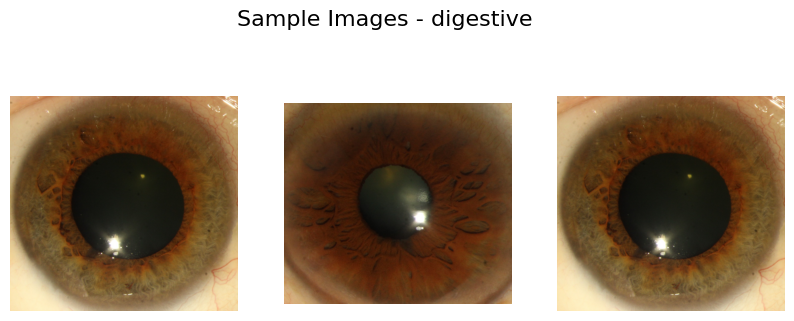

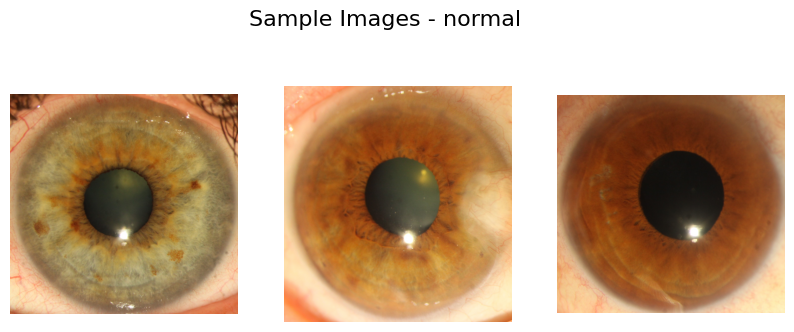

In [3]:
path = '/content/drive/MyDrive/Research/New folder'
classes = ['digestive', 'normal']

# ==========================================
# 3. VISUALIZE SAMPLE IMAGES
# ==========================================
for cat in classes:
    image_dir = f'{path}/{cat}'
    images = os.listdir(image_dir)

    fig, ax = plt.subplots(1, 3, figsize=(10, 4))
    fig.suptitle(f'Sample Images - {cat}', fontsize=16)

    for i in range(3):
        img = np.array(Image.open(os.path.join(image_dir, images[np.random.randint(len(images))])))
        ax[i].imshow(img)
        ax[i].axis('off')
    plt.show()


In [5]:
# ==========================================
# 4. PARAMETERS
# ==========================================
IMG_SIZE = 256
BATCH_SIZE = 64
EPOCHS_PHASE1 = 20
EPOCHS_PHASE2 = 20
SPLIT = 0.2

# ==========================================
# 5. LOAD & PREPROCESS DATA
# ==========================================
X, Y = [], []

for i, cat in enumerate(classes):
    images = glob(f'{path}/{cat}/*.JPG')

    for image in images:
        img = cv2.imread(image)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # IMPORTANT
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        X.append(img)
        Y.append(i)

X = np.array(X, dtype="float32")
Y = np.array(Y)

Y_cat = keras.utils.to_categorical(Y, num_classes=len(classes))

X_train, X_val, Y_train, Y_val = train_test_split(
    X, Y_cat, test_size=SPLIT, random_state=42, stratify=Y
)

print(f"Train: {X_train.shape}, Validation: {X_val.shape}")

Train: (124, 256, 256, 3), Validation: (32, 256, 256, 3)


In [6]:
# ==========================================
# 6. CLASS WEIGHTS (OPTIONAL BUT RECOMMENDED)
# ==========================================
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(Y),
    y=Y
)
class_weights = dict(enumerate(class_weights))
print("Class Weights:", class_weights)

Class Weights: {0: np.float64(1.0), 1: np.float64(1.0)}


In [7]:
# ==========================================
# 7. DATA AUGMENTATION
# ==========================================
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.2),
    layers.RandomBrightness(0.2),
], name="augmentation")


In [11]:
def cbam_block(input_tensor, ratio=8):
    channel = input_tensor.shape[-1]

    # ----- Channel Attention -----
    avg_pool = layers.GlobalAveragePooling2D()(input_tensor)
    max_pool = layers.GlobalMaxPooling2D()(input_tensor)

    shared_dense_1 = layers.Dense(channel // ratio, activation='relu')
    shared_dense_2 = layers.Dense(channel, activation='sigmoid')

    avg_out = shared_dense_2(shared_dense_1(avg_pool))
    max_out = shared_dense_2(shared_dense_1(max_pool))

    channel_attention = layers.Add()([avg_out, max_out])
    channel_attention = layers.Reshape((1, 1, channel))(channel_attention)

    x = layers.Multiply()([input_tensor, channel_attention])

    # ----- Spatial Attention -----
    avg_pool_spatial = layers.Lambda(
        lambda x: K.mean(x, axis=-1, keepdims=True)
    )(x)
    max_pool_spatial = layers.Lambda(
        lambda x: K.max(x, axis=-1, keepdims=True)
    )(x)

    spatial_attention = layers.Concatenate(axis=-1)(
        [avg_pool_spatial, max_pool_spatial]
    )
    spatial_attention = layers.Conv2D(
        1, kernel_size=7, padding="same", activation="sigmoid"
    )(spatial_attention)

    x = layers.Multiply()([x, spatial_attention])

    return x


In [12]:
input_layer = Input(shape=(IMG_SIZE, IMG_SIZE, 3))

x = data_augmentation(input_layer)

mobile_input = mobilenet_preprocess(x)
dense_input = densenet_preprocess(x)

# =======================
# MobileNetV2 Branch
# =======================
base_mobile = MobileNetV2(
    include_top=False,
    weights='imagenet',
    input_tensor=mobile_input
)
base_mobile.trainable = False

mobile_feat = base_mobile.output
mobile_feat = cbam_block(mobile_feat)
mobile_feat = layers.GlobalAveragePooling2D()(mobile_feat)

# =======================
# DenseNet121 Branch
# =======================
base_dense = DenseNet121(
    include_top=False,
    weights='imagenet',
    input_tensor=dense_input
)
base_dense.trainable = False

dense_feat = base_dense.output
dense_feat = cbam_block(dense_feat)
dense_feat = layers.GlobalAveragePooling2D()(dense_feat)

# =======================
# Feature Fusion
# =======================
combined = layers.Concatenate()([mobile_feat, dense_feat])

# =======================
# Classification Head
# =======================
x = layers.Dense(512, activation='relu')(combined)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.6)(x)

x = layers.Dense(256, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.4)(x)

output = layers.Dense(len(classes), activation='softmax')(x)

model = Model(inputs=input_layer, outputs=output)
model.summary()


/tmp/ipython-input-2274094767.py:11: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_mobile = MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ augmentation        │ (None, 256, 256,  │          0 │ input_layer_2[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ true_divide_1       │ (None, 256, 256,  │          0 │ augmentation[1][… │
│ (TrueDivide)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 256, 256,  │          0 │ true_divide_1[0]… │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ true_divide_2       │ (None, 256, 256,  │          0 │ add[0][0]         │
│ (TrueDivide)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 262, 262,  │          0 │ true_divide_2[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 128, 128,  │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 128, 128,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 128, 128,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 130, 130,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 64, 64,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 64, 64,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 64, 64,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 64, 64,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 64, 64,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 64, 64,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 64, 64,    │     36,864 │ conv2_block1_1_r

 Total params: 11,285,096 (43.05 MB)

 Trainable params: 1,988,072 (7.58 MB)

 Non-trainable params: 9,297,024 (35.47 MB)

In [13]:
def grad_cam(model, img_array, last_conv_layer_name, pred_index=None):
    grad_model = Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        loss = predictions[:, pred_index]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0)
    heatmap /= tf.math.reduce_max(heatmap)

    return heatmap.numpy()


In [14]:
def show_gradcam(img_path, model, last_conv_layer):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img_array = np.expand_dims(img, axis=0)
    img_array = img_array.astype("float32")

    heatmap = grad_cam(model, img_array, last_conv_layer)

    heatmap = cv2.resize(heatmap, (IMG_SIZE, IMG_SIZE))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    superimposed = cv2.addWeighted(img, 0.6, heatmap, 0.4, 0)

    plt.figure(figsize=(6, 6))
    plt.imshow(superimposed)
    plt.axis("off")
    plt.title("Grad-CAM")
    plt.show()


In [15]:
# ==========================================
# 9. COMPILE (PHASE 1)
# ==========================================
model.compile(
    optimizer=keras.optimizers.Adam(1e-4),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=["accuracy"]
)


In [16]:
# ==========================================
# 10. TRAINING – PHASE 1 (FEATURE EXTRACTION)
# ==========================================
history_1 = model.fit(
    X_train, Y_train,
    validation_data=(X_val, Y_val),
    epochs=EPOCHS_PHASE1,
    batch_size=BATCH_SIZE,
    class_weight=class_weights,
    verbose=1
)


Epoch 1/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 44s 12s/step - accuracy: 0.5326 - loss: 1.2918 - val_accuracy: 0.5000 - val_loss: 0.7744
Epoch 2/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 725ms/step - accuracy: 0.4464 - loss: 1.3542 - val_accuracy: 0.5000 - val_loss: 0.7277
Epoch 3/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 739ms/step - accuracy: 0.5168 - loss: 1.1123 - val_accuracy: 0.5000 - val_loss: 0.6860
Epoch 4/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 741ms/step - accuracy: 0.6226 - loss: 1.0060 - val_accuracy: 0.5312 - val_loss: 0.6406
Epoch 5/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 687ms/step - accuracy: 0.6815 - loss: 0.8927 - val_accuracy: 0.6250 - val_loss: 0.5985
Epoch 6/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 690ms/step - accuracy: 0.7445 - loss: 0.6790 - val_accuracy: 0.6562 - val_loss: 0.5654
Epoch 7/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 693ms/step - accuracy: 0.7453 - loss: 0.6812 - val_accuracy: 0.7188 - val_loss: 0.5389
Epoch 8/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 690ms/step - accuracy: 0.7181 - loss: 0.7768 - val_accuracy: 0.7500 - val_loss: 

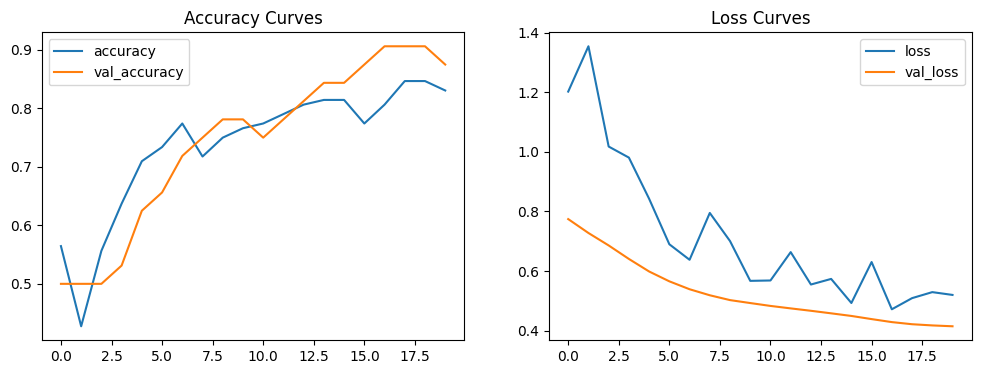

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 308ms/step


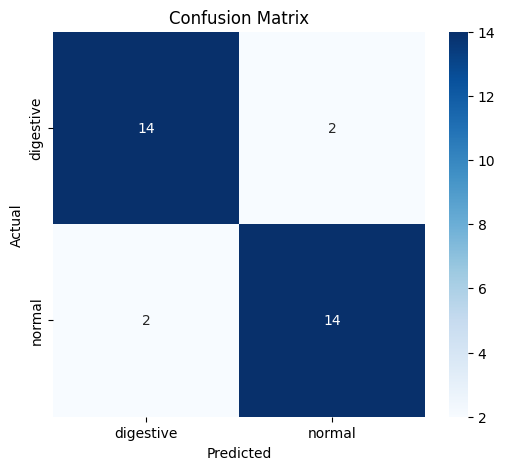

In [20]:
# Plot Accuracy and Loss
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
history_df = pd.DataFrame(history_1.history)

history_df[['accuracy', 'val_accuracy']].plot(ax=ax[0])
ax[0].set_title('Accuracy Curves')

history_df[['loss', 'val_loss']].plot(ax=ax[1])
ax[1].set_title('Loss Curves')
plt.show()

# Confusion Matrix
Y_pred = model.predict(X_val)
Y_pred_classes = np.argmax(Y_pred, axis=1)
Y_true = np.argmax(Y_val, axis=1)

cm = confusion_matrix(Y_true, Y_pred_classes)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=classes, yticklabels=classes, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [23]:
# ==========================================
# 11. FINE-TUNING (PHASE 2)
# ==========================================
for layer in base_mobile.layers[-30:]:
    layer.trainable = True

for layer in base_dense.layers[-30:]:
    layer.trainable = True

model.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

history_2 = model.fit(
    X_train, Y_train,
    validation_data=(X_val, Y_val),
    epochs=EPOCHS_PHASE2,
    batch_size=BATCH_SIZE,
    class_weight=class_weights,
    verbose=1
)


model.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=["accuracy"]
)

history_2 = model.fit(
    X_train, Y_train,
    validation_data=(X_val, Y_val),
    epochs=EPOCHS_PHASE2,
    batch_size=BATCH_SIZE,
    class_weight=class_weights,
    verbose=1
)

Epoch 1/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 42s 9s/step - accuracy: 0.6272 - loss: 1.0016 - val_accuracy: 0.9062 - val_loss: 0.4103
Epoch 2/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 739ms/step - accuracy: 0.6067 - loss: 0.9449 - val_accuracy: 0.9062 - val_loss: 0.4070
Epoch 3/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 756ms/step - accuracy: 0.6065 - loss: 0.9233 - val_accuracy: 0.9062 - val_loss: 0.4042
Epoch 4/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 736ms/step - accuracy: 0.6384 - loss: 0.8801 - val_accuracy: 0.9062 - val_loss: 0.4018
Epoch 5/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 731ms/step - accuracy: 0.6275 - loss: 0.9108 - val_accuracy: 0.9062 - val_loss: 0.3994
Epoch 6/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 739ms/step - accuracy: 0.6648 - loss: 0.9484 - val_accuracy: 0.9062 - val_loss: 0.3970
Epoch 7/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 747ms/step - accuracy: 0.7339 - loss: 0.7716 - val_accuracy: 0.9062 - val_loss: 0.3948
Epoch 8/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 734ms/step - accuracy: 0.6490 - loss: 0.9259 - val_accuracy: 0.9062 - val_loss: 0

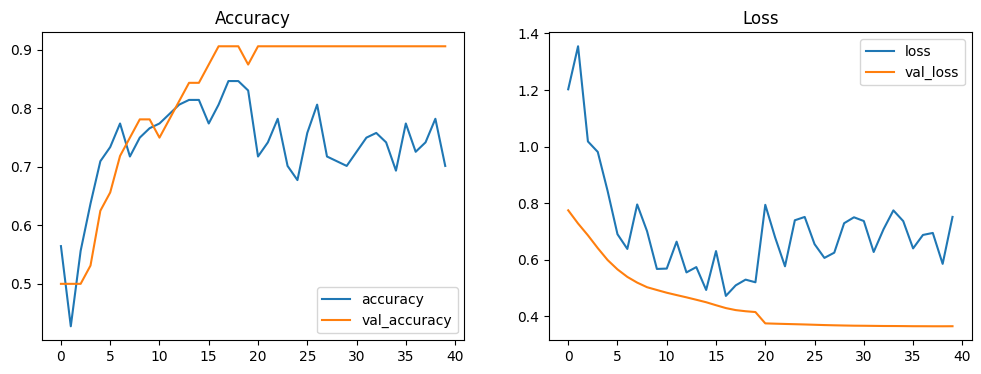

In [24]:
# ==========================================
# 12. TRAINING CURVES
# ==========================================
history = pd.concat([
    pd.DataFrame(history_1.history),
    pd.DataFrame(history_2.history)
], ignore_index=True)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
history[['accuracy', 'val_accuracy']].plot(ax=ax[0])
ax[0].set_title("Accuracy")

history[['loss', 'val_loss']].plot(ax=ax[1])
ax[1].set_title("Loss")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
              precision    recall  f1-score   support

   digestive       0.93      0.88      0.90        16
      normal       0.88      0.94      0.91        16

    accuracy                           0.91        32
   macro avg       0.91      0.91      0.91        32
weighted avg       0.91      0.91      0.91        32



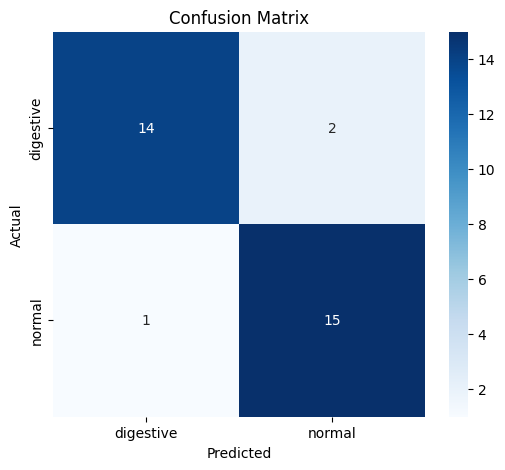

In [25]:
# ==========================================
# 13. EVALUATION
# ==========================================
Y_pred = model.predict(X_val)
Y_pred_cls = np.argmax(Y_pred, axis=1)
Y_true = np.argmax(Y_val, axis=1)

print(classification_report(Y_true, Y_pred_cls, target_names=classes))

cm = confusion_matrix(Y_true, Y_pred_cls)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()